# Klasifikasi Penyakit Daun Jagung Menggunakan Ekstraksi Fitur Tekstur (GLCM) Berbasis K-Nearest Neighbor (KNN)

Penelitian ini menggunakan metode ekstraksi fitur tekstur GLCM dan algoritma K-Nearest Neighbor (KNN) untuk mengklasifikasikan penyakit daun jagung. Fitur yang digunakan meliputi contrast, homogeneity, energy, dan correlation. Model KNN mengklasifikasikan citra ke dalam kelas Hawar, Karat, dan Sehat berdasarkan kedekatan jarak fitur. Hasil menunjukkan bahwa metode ini cukup efektif dengan performa yang dianalisis menggunakan akurasi dan confusion matrix.

## **1. Mounting Google Drive pada Google Colab**

Mounting Google Drive dilakukan untuk menghubungkan Colab dengan Google Drive agar file dapat diakses dan disimpan secara langsung.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **2. Import Library**

Library yang digunakan meliputi OpenCV untuk pengolahan citra, NumPy untuk komputasi numerik, scikit-learn untuk machine learning, skimage untuk ekstraksi fitur GLCM, serta matplotlib, seaborn, dan pandas untuk visualisasi dan pengolahan data.

In [ ]:
import cv2
import numpy as np
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder

from skimage.feature import graycomatrix, graycoprops

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

## **3. Inisialisasi dan Pengecekan Dataset**

Kode ini digunakan untuk menentukan lokasi dataset dan mengecek jumlah data pada setiap kelas untuk memastikan dataset siap digunakan.

In [ ]:
dataset_path = '/content/drive/MyDrive/Colab Notebooks/Comvis/Uts/Penyakit Daun Jagung'

print("Isi dataset:", os.listdir(dataset_path))

for label in os.listdir(dataset_path):
    folder = os.path.join(dataset_path, label)

    if not os.path.isdir(folder):
        continue

    print(label, ":", len(os.listdir(folder)))

Isi dataset: ['Hawar', 'Sehat', 'Karat']
Hawar : 107
Sehat : 101
Karat : 102


## **4. Ekstraksi Fitur Tekstur Menggunakan GLCM**

Ekstraksi fitur dilakukan menggunakan metode GLCM untuk memperoleh fitur tekstur berupa contrast, homogeneity, energy, dan correlation dari citra grayscale.

In [ ]:
def extract_glcm_features(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    glcm = graycomatrix(
        gray,
        distances=[1],
        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
        levels=256,
        symmetric=True,
        normed=True
    )

    contrast = graycoprops(glcm, 'contrast').flatten()
    homogeneity = graycoprops(glcm, 'homogeneity').flatten()
    energy = graycoprops(glcm, 'energy').flatten()
    correlation = graycoprops(glcm, 'correlation').flatten()

    return np.hstack([contrast, homogeneity, energy, correlation])

## **5. Proses Loading Data dan Ekstraksi Fitur**

Kode ini digunakan untuk membaca dataset, melakukan resize citra, mengekstraksi fitur GLCM, serta menyimpan fitur dan label ke dalam array untuk proses klasifikasi.

In [ ]:
data = []
labels = []
images = []

for label in os.listdir(dataset_path):
    folder = os.path.join(dataset_path, label)

    if not os.path.isdir(folder):
        continue

    for file in os.listdir(folder):
        path = os.path.join(folder, file)

        img = cv2.imread(path)
        if img is None:
            continue

        try:
            img = cv2.resize(img, (128,128))
            feat = extract_glcm_features(img)

            data.append(feat)
            labels.append(label)
            images.append(img)
        except:
            continue

data = np.array(data)
labels = np.array(labels)

print("Jumlah data:", len(data))

Jumlah data: 310


## 6.Transformasi Label Menggunakan **LabelEncoder**

LabelEncoder digunakan untuk mengubah label kelas dari teks menjadi angka agar dapat diproses oleh algoritma KNN.

In [ ]:
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

print("Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Mapping: {np.str_('Hawar'): np.int64(0), np.str_('Karat'): np.int64(1), np.str_('Sehat'): np.int64(2)}


## **7. Normalisasi Data Menggunakan StandardScaler**

StandardScaler digunakan untuk menormalkan data agar semua fitur memiliki skala yang seimbang sebelum digunakan dalam KNN.

In [ ]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

## **8. Pembagian Data Training dan Testing**

Data dibagi menjadi data latih (80%) dan data uji (20%) untuk melatih dan mengevaluasi model KNN.

In [ ]:
X_train, X_test, y_train, y_test, img_train, img_test = train_test_split(
    data_scaled, labels_encoded, images,
    test_size=0.2, random_state=42, stratify=labels_encoded
)

## **9. Optimasi Parameter KNN Menggunakan GridSearchCV**

GridSearchCV digunakan untuk mencari parameter terbaik pada KNN agar menghasilkan akurasi yang optimal.

In [ ]:
param_grid = {
    'n_neighbors': [3,5,7],
    'weights': ['uniform','distance']
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

model = grid.best_estimator_
print("Best Parameter:", grid.best_params_)

Best Parameter: {'n_neighbors': 7, 'weights': 'distance'}


## **10. Evaluasi Model KNN**

Evaluasi dilakukan untuk mengukur performa model KNN menggunakan akurasi dan classification report.

In [ ]:
y_pred = model.predict(X_test)

print("Akurasi:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Akurasi: 0.7258064516129032

Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.50      0.56        22
           1       0.70      0.70      0.70        20
           2       0.80      1.00      0.89        20

    accuracy                           0.73        62
   macro avg       0.72      0.73      0.72        62
weighted avg       0.71      0.73      0.71        62



## **11. Visualisasi Confusion Matrix**

Confusion matrix digunakan untuk melihat perbandingan antara label asli dan hasil prediksi model dalam bentuk visual heatmap.

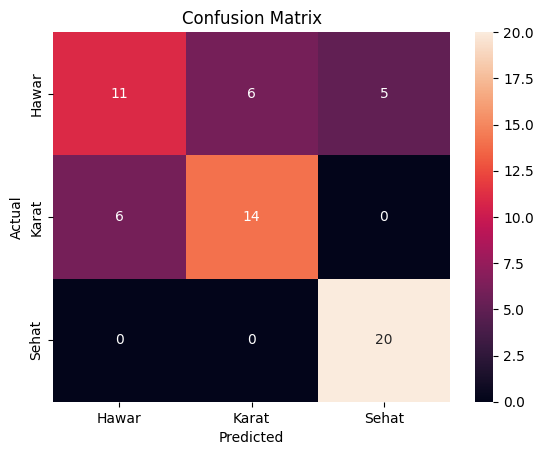

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## **12. Analisis Pengaruh Nilai K terhadap Akurasi**

Grafik ini menunjukkan hubungan antara nilai K pada KNN dengan akurasi model untuk menentukan nilai K terbaik.

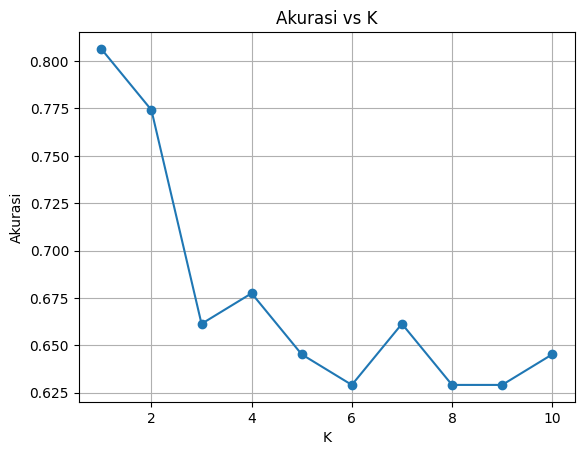

In [ ]:
k_values = range(1, 11)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred_k = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred_k))

plt.figure()
plt.plot(k_values, accuracies, marker='o')
plt.title("Akurasi vs K")
plt.xlabel("K")
plt.ylabel("Akurasi")
plt.grid()
plt.show()

## **13. Visualisasi Hasil Prediksi Citra**

Visualisasi ini menampilkan beberapa citra uji beserta hasil prediksi dan label aslinya untuk melihat performa model secara langsung.

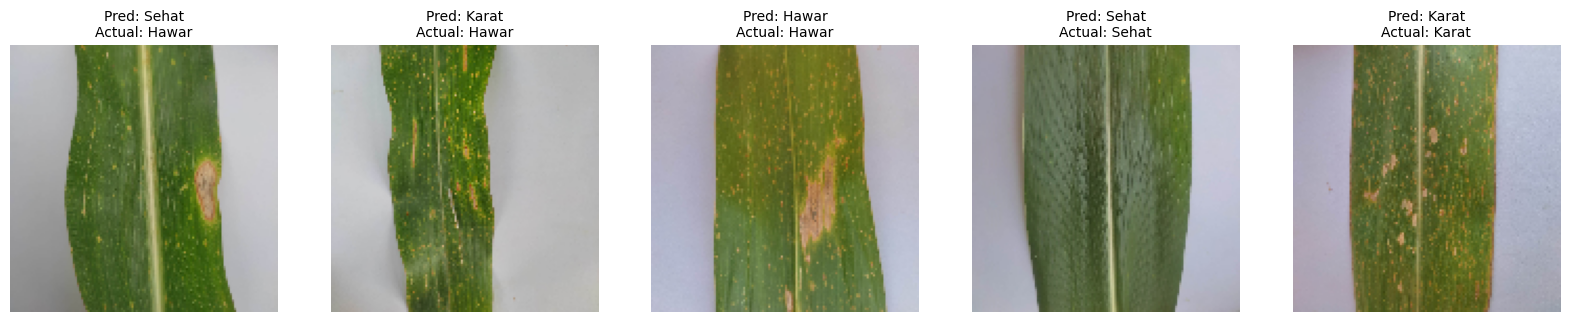

In [ ]:
n = 5
plt.figure(figsize=(20,4))

for i in range(n):
    img = img_test[i]

    pred = le.inverse_transform([y_pred[i]])[0]
    actual = le.inverse_transform([y_test[i]])[0]

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax = plt.subplot(1, n, i+1)
    ax.imshow(img_rgb)
    ax.set_title(f"Pred: {pred}\nActual: {actual}", fontsize=10)
    ax.axis("off")

plt.show()

## **14. Penyimpanan Data Fitur dan Hasil Prediksi ke Google Drive**

Data fitur dan hasil prediksi disimpan ke dalam file Excel di Google Drive untuk keperluan analisis dan dokumentasi.

In [ ]:
save_path = "/content/drive/MyDrive/Colab Notebooks/Comvis/Uts/Penyakit Daun Jagung"

feature_names = [f"Fitur_{i+1}" for i in range(data.shape[1])]

df_features = pd.DataFrame(data, columns=feature_names)
df_features['Label'] = labels

df_result = pd.DataFrame({
    'Actual': le.inverse_transform(y_test),
    'Predicted': le.inverse_transform(y_pred)
})

df_result['Status'] = df_result['Actual'] == df_result['Predicted']

# SIMPAN
df_features.to_excel(save_path + "fitur_dataset.xlsx", index=False)
df_result.to_excel(save_path + "hasil_prediksi.xlsx", index=False)

print("✅ Excel berhasil disimpan di Google Drive!")

✅ Excel berhasil disimpan di Google Drive!


##**15. Kesimpulan**

Berdasarkan penelitian yang telah dilakukan, dapat disimpulkan bahwa metode ekstraksi fitur tekstur menggunakan Gray Level Co-occurrence Matrix (GLCM) mampu merepresentasikan karakteristik citra daun jagung dengan baik. Fitur yang digunakan meliputi contrast, homogeneity, energy, dan correlation yang berhasil menangkap pola tekstur dari setiap citra.

Metode klasifikasi K-Nearest Neighbor (KNN) yang digunakan menunjukkan performa yang cukup baik dalam mengklasifikasikan citra ke dalam kelas Hawar, Karat, dan Sehat. Proses optimasi parameter menggunakan GridSearchCV juga membantu dalam meningkatkan akurasi model.

Hasil evaluasi menggunakan akurasi, classification report, dan confusion matrix menunjukkan bahwa model mampu melakukan klasifikasi dengan cukup efektif, meskipun masih terdapat beberapa kesalahan prediksi antar kelas.

Secara keseluruhan, kombinasi metode GLCM dan KNN dapat digunakan sebagai pendekatan sederhana namun efektif dalam klasifikasi citra berbasis tekstur. Untuk pengembangan lebih lanjut, model dapat ditingkatkan dengan menambahkan fitur lain atau menggunakan metode klasifikasi yang lebih kompleks.